
# CAM Tutorial (GoogLeNet, ImageNet)

This notebook demonstrates **Class Activation Mapping (CAM)** in the original, simple sense: **convolutions → global average pooling (GAP) → linear → softmax**. We use torchvision.models.googlenet pretrained on ImageNet, which fits the CAM requirement naturally.

**What you'll learn** (20 minutes)
- Load a pretrained ImageNet model with a GAP head.
- Hook the **feature maps before GAP** and read the **linear classifier weights**.
- Compute a **class activation map** for the predicted class (or a chosen class).
- Overlay the CAM on the input image for visualization.


<img src="./static/cam.jpg" alt="LO1 Image" style="width: 50%; height: auto;">  

In [1]:
# Import necessary libraries
import os # For file path operations
import torch # For tensor operations and deep learning
import numpy as np # For numerical operations
import torch.nn as nn # For neural network layers
from PIL import Image # For image processing
from torchvision import models, transforms # For pre-trained models and image transformations
import torch.nn.functional as F # For functional operations
from utils import denormalize, overlay_cam_on_image # For image denormalization and CAM overlay
import matplotlib.pyplot as plt

# Use CPU by default since no training is being done
device = torch.device('cpu')

### 1. Loading the Pre-trained Model

In [2]:
# Load pretrained GoogLeNet (ImageNet). It already uses conv → GAP → linear and has been trained on ImageNet (1000 classes)
googlenet_weights = models.GoogLeNet_Weights.IMAGENET1K_V1 # pretrained weights for GoogLeNet v1
model = models.googlenet(weights=googlenet_weights) # load the model
model.eval().to(device); # set to evaluation mode and move to device

We just loaded this model: GoogLeNet Architecture. Intermediate output predictions are used to counteract the vanishing gradient problem of very deep NNs. Perfect architecture because of Conv into GAP into Softmax.  

<img src="./static/GoogLeNet.png" alt="LO1 Image" style="width: 90%; height: auto;">  

### 2. Setting Up a "Hook" to Capture Feature Maps

How do we get the output of an intermediate layer? When we run model(image), we only get the final output. We need a way to "spy" on the data as it flows through the network. This is what a PyTorch **hook** is used for. A hook is like a little function you can attach to any layer in your model. When the forward pass happens, your hook function is automatically called, and it gets access to the layer's input and output.

In [3]:
# We will hook the input to model.avgpool (i.e., the final feature maps before GAP)
feature_maps = None

# This is our "spy" function. PyTorch will automatically pass it three arguments:
# module: The layer the hook is attached to (in this case, model.avgpool).
# input: A tuple containing the tensor(s) going into the layer.
# output: The tensor coming out of the layer.

def hook_feature_maps(module, input, output):
    # input is a tuple; take the tensor prior to GAP
    global feature_maps # The feature_maps variable was created outside the function. To modify it from inside the function, we must tell Python it's a global variable
    feature_maps = input[0].detach()  # [B, C, H, W]  Since input is a tuple, we take the first element [0], which is the tensor of feature maps.

# This is the line that actually attaches our hook_feature_maps function to the model.avgpool layer. 
# The hook_handle is an object that we can use later to remove the hook when we're done with it (hook_handle.remove()).
hook_handle = model.avgpool.register_forward_hook(hook_feature_maps)

### 3. Getting the Weights

In [4]:
# The linear classifier weights (shape [num_classes, C])

# This directly accesses the weights of the final fully connected (linear) layer, which is named fc in the GoogLeNet model. 
# This tensor has a shape of (number of classes, number of input features), which for ImageNet is (1000, 1024)
fc_weight = model.fc.weight.detach().cpu().numpy()

 # The googlenet_weights object we created earlier contains metadata, including the human-readable names for all 1000 ImageNet classes
 # You can look at what the model should be capable of classifying by inspecting these class names.
class_names = googlenet_weights.meta.get('categories', None);

print('Classifier weight shape:', fc_weight.shape) # here 1024 is the number of input features to the classifier

Classifier weight shape: (1000, 1024)


### 4. Transform the image to be compatible with the model 

In [5]:
# Image preprocessing for ImageNet compatibility
preprocess = transforms.Compose([
    transforms.Resize(256), # shorter side resized to 256
    transforms.CenterCrop(224), # center crop to 224x224
    transforms.ToTensor(), # convert PIL image to tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                         std=[0.229, 0.224, 0.225]), # normalize with ImageNet stats
])

### 5. CAM computation: 
$\text{CAM}_c(x, y) = \sum_k w_{c,k} * F_k(x, y)$

In [6]:
def compute_cam_for_class(fmaps: torch.Tensor, class_idx: int, fc_weight: np.ndarray):

    C, H, W = fmaps.shape[1:]

    w = torch.from_numpy(fc_weight[class_idx]).view(C, 1, 1)

    cam = torch.sum(fmaps[0] * w.to(fmaps.device), dim=0)

    cam = F.relu(cam)

    cam = cam - cam.min()
    if cam.max() > 0:
        cam = cam / cam.max()

    return cam.cpu().numpy()

### 6. Provide your own image here and calculate the models attention

In [7]:
path = "../data/dog.jpg"

orig_img = Image.open(path).convert('RGB')
x = preprocess(orig_img).unsqueeze(0).to(device)

with torch.no_grad():
    logits = model(x)
    probs = torch.softmax(logits, dim=1)[0]
    top_prob, top_idx = probs.max(dim=0)

fmap = feature_maps
cam = compute_cam_for_class(fmap, int(top_idx.item()), fc_weight)

### 7. Visualize result

Top-1: Labrador retriever (p=0.732)


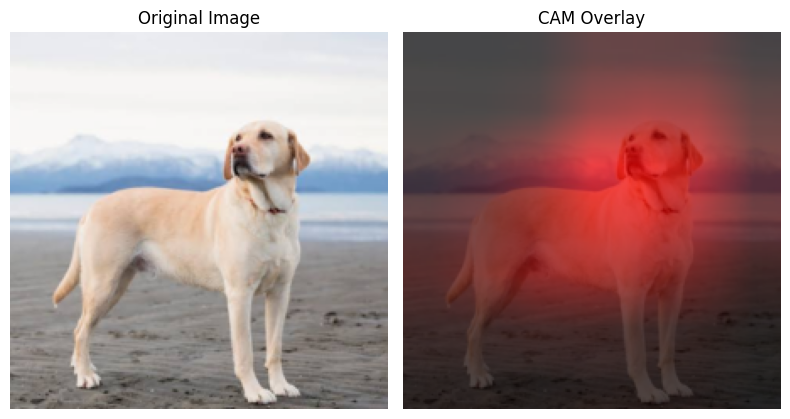

In [8]:
x_denorm = denormalize(x[0].cpu())
overlay = overlay_cam_on_image(x_denorm, cam, alpha=0.7) # n.b., this helper function interpolates the cam back to image size
# Titles
pred_name = class_names[int(top_idx)] if class_names is not None else str(int(top_idx))
print(f"Top-1: {pred_name} (p={float(top_prob):.3f})")
center_img = Image.fromarray((x_denorm.permute(1,2,0).numpy() * 255).astype('uint8'))

# Create a figure with 1 row and 2 columns for our subplots
fig, axes = plt.subplots(1, 2, figsize=(8, 5))
# Display the original image on the first subplot (axes[0])
axes[0].imshow(center_img)
axes[0].set_title("Original Image")
axes[0].axis('off')  # Hide the x/y axes
# Display the CAM overlay on the second subplot (axes[1])
axes[1].imshow(overlay)
axes[1].set_title("CAM Overlay")
axes[1].axis('off')  # Hide the x/y axes
# Show the final plot, tight layout and close
plt.tight_layout()
plt.show()
plt.close()

### 8. Experiments

- **Take your own picture** or download one from the internet, upload it, and compute the CAM.
- **Remove the ReLU** in `compute_cam_for_class` and compare — what do negative weights contribute?
- **Substitute a false target label** (e.g., pass a wrong class index) and explain what the CAM highlights.

**Own image (rocket.jpg):** The model predicted "drilling platform" with only 8.8% confidence — there is no rocket class in ImageNet so it falls back to the most similar shape it has seen. I think the choice of drilling platform makes sense since it's also a tall elongated structure. The CAM highlights the body of the rocket which is what drives the prediction.

**Without ReLU:** Now that the visualization uses a diverging colormap I can clearly see two types of regions — red areas that support the prediction and blue areas that actively suppress it. The rocket body is red as expected, while the background shows up in blue. I find this much more informative than the original map which was just cutting the blue out entirely with the ReLU.

**Wrong class (pizza):** The CAM shifts to a completely different part of the image — probably some round or warm-coloured patch in the background. I think the model just latches onto whatever weakly matches pizza-like features since there's nothing really pizza-shaped in a rocket image. The spatial highlight makes no intuitive sense, which is kind of the point.

Top-1: drilling platform (p=0.088)


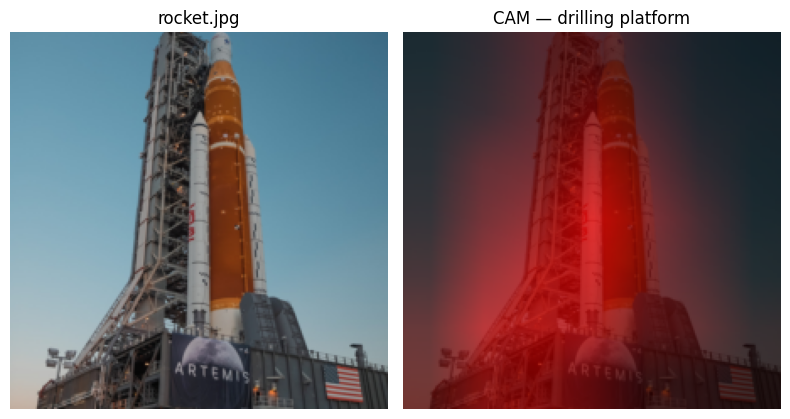

In [9]:
# Experiment 1: 
path = "../data/rocket.jpg"

orig_img = Image.open(path).convert('RGB')
x = preprocess(orig_img).unsqueeze(0).to(device)

with torch.no_grad():
    logits = model(x)
    probs = torch.softmax(logits, dim=1)[0]
    top_prob, top_idx = probs.max(dim=0)

fmap = feature_maps
cam = compute_cam_for_class(fmap, int(top_idx.item()), fc_weight)

x_denorm = denormalize(x[0].cpu())
overlay = overlay_cam_on_image(x_denorm, cam, alpha=0.7)
pred_name = class_names[int(top_idx)]
print(f"Top-1: {pred_name} (p={float(top_prob):.3f})")

fig, axes = plt.subplots(1, 2, figsize=(8, 5))
axes[0].imshow(Image.fromarray((x_denorm.permute(1,2,0).numpy() * 255).astype('uint8')))
axes[0].set_title("rocket.jpg")
axes[0].axis('off')
axes[1].imshow(overlay)
axes[1].set_title(f"CAM — {pred_name}")
axes[1].axis('off')
plt.tight_layout()
plt.show()

The model predicted "drilling platform" with only 8.8% confidence — there is no rocket class in ImageNet so it falls back to the most similar shape it has seen. A drilling platform is also a tall, elongated structure, which explains the choice. The CAM highlights the body of the rocket since that's what drives the prediction.

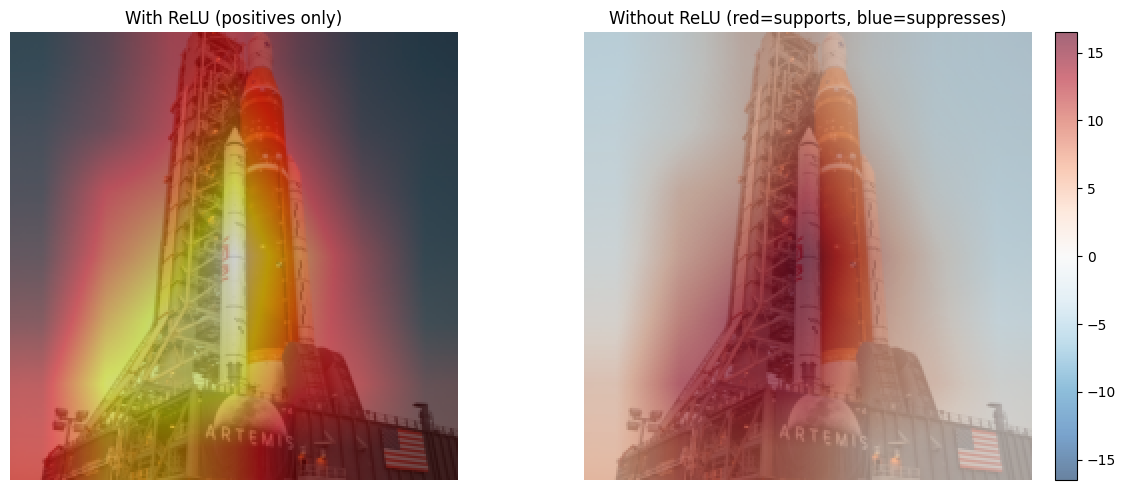

In [10]:
# Experiment 2: remove ReLU and compare
# The original function normalises with (cam - cam.min()) which shifts negatives up to ~0,
# making both maps look identical. We need raw signed values + a diverging colormap instead.

def compute_cam_raw(fmaps, class_idx, fc_weight):
    C, H, W = fmaps.shape[1:]
    w = torch.from_numpy(fc_weight[class_idx]).view(C, 1, 1)
    cam = torch.sum(fmaps[0] * w.to(fmaps.device), dim=0)
    return cam.cpu().numpy()  # keep sign — no ReLU, no shift

cam_relu = compute_cam_for_class(fmap, int(top_idx.item()), fc_weight)
cam_raw  = compute_cam_raw(fmap, int(top_idx.item()), fc_weight)

img_np = x_denorm.permute(1, 2, 0).numpy()
# resize both maps to image size for overlay
import torch.nn.functional as F2
def resize_map(m, h, w):
    t = torch.from_numpy(m).unsqueeze(0).unsqueeze(0)
    return F2.interpolate(t, size=(h, w), mode='bilinear', align_corners=False).squeeze().numpy()

H, W = img_np.shape[:2]
cam_relu_up = resize_map(cam_relu, H, W)
cam_raw_up  = resize_map(cam_raw,  H, W)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(img_np)
axes[0].imshow(cam_relu_up, cmap='hot', alpha=0.5, vmin=0, vmax=1)
axes[0].set_title("With ReLU (positives only)")
axes[0].axis('off')

# diverging colormap: red = positive evidence, blue = suppression
vmax = np.abs(cam_raw_up).max()
axes[1].imshow(img_np)
im = axes[1].imshow(cam_raw_up, cmap='RdBu_r', alpha=0.6, vmin=-vmax, vmax=vmax)
axes[1].set_title("Without ReLU (red=supports, blue=suppresses)")
axes[1].axis('off')
plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

Now that the visualization uses a diverging colormap you can clearly see two types of regions — red areas that support the "drilling platform" prediction and blue areas that actively suppress it. The rocket body is red as expected, while the surrounding background shows up in blue, meaning those regions are actually working against the prediction. The ReLU version was only showing you half the picture by cutting the blue regions out entirely.

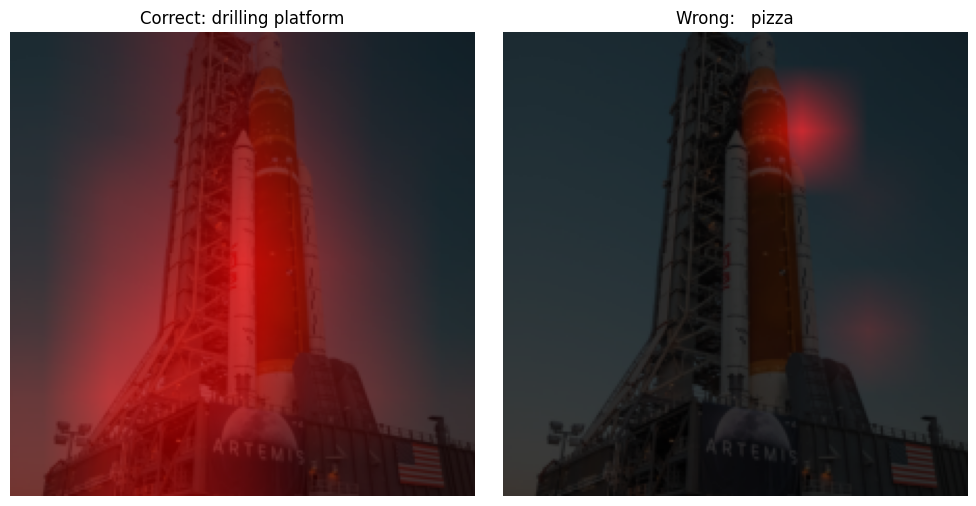

In [11]:
# Experiment 3: 
# Pick a clearly wrong class and see what the model "looks for"
wrong_class_idx = 963  # pizza
wrong_name = class_names[wrong_class_idx]

cam_wrong = compute_cam_for_class(fmap, wrong_class_idx, fc_weight)
overlay_correct = overlay_cam_on_image(x_denorm, cam_relu,  alpha=0.7)
overlay_wrong   = overlay_cam_on_image(x_denorm, cam_wrong, alpha=0.7)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(overlay_correct); axes[0].set_title(f"Correct: {pred_name}"); axes[0].axis('off')
axes[1].imshow(overlay_wrong);   axes[1].set_title(f"Wrong:   {wrong_name}"); axes[1].axis('off')
plt.tight_layout()
plt.show()

The CAM shifts to a completely different part of the image — some round or warm-coloured patch that weakly resembles pizza texture. The model has to find pizza-like evidence somewhere in the rocket image so it latches onto whatever matches least badly. The spatial highlight makes no intuitive sense, which is exactly the point.